In [20]:
!pip install mglearn --q

In [21]:
import numpy as np
import pandas as pd
import mglearn as mg
from sklearn.neural_network import MLPClassifier

In [22]:
from sklearn.datasets import make_moons

In [23]:
X, Y = make_moons(noise=0.15, random_state=0)

In [24]:
x1, x2 = X[:,0], X[:,1]

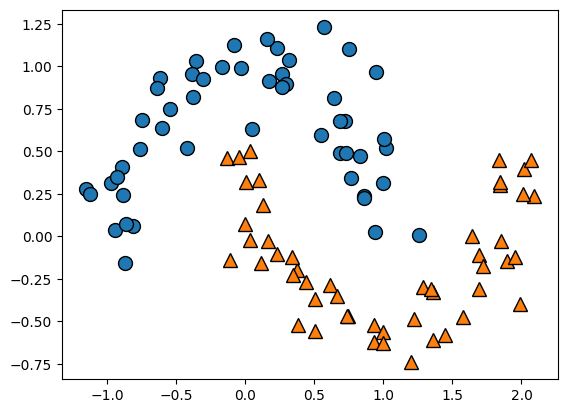

In [25]:
mg.discrete_scatter(x1, x2, Y)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


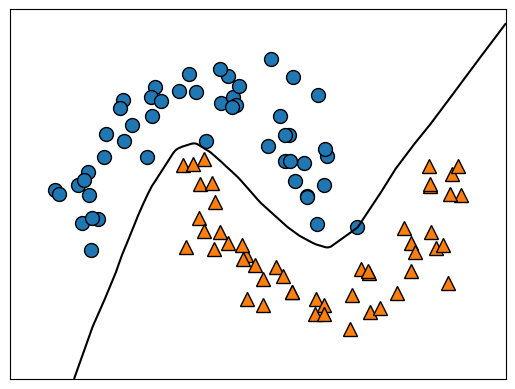

In [38]:
model = MLPClassifier((50,50,30))
model.fit(X, Y)
mg.discrete_scatter(x1, x2, Y)
mg.plots.plot_2d_separator(model, X)

# Pytorch Equivalent Code

In [39]:
import torch

In [40]:
Xn = torch.FloatTensor(X)
Yn = torch.LongTensor(Y)

In [41]:
x1n, x2n = Xn[:,0], Xn[:,1]

# Network Design

In [43]:
from torch import nn
from torch.optim import SGD, Adam

In [45]:
model = nn.Sequential(
    nn.Linear(2, 50),
    nn.Linear(50, 50),
    nn.Linear(50, 30),
    nn.Linear(30, 2)  # nn.Linear(30, 1) for regression
)

In [47]:
# nn.MSELoss() for Regression
lossfn = nn.CrossEntropyLoss() # for classification

In [48]:
optimiz = Adam(model.parameters(), lr=0.01)

# process of gradient descent is getting started

In [50]:
for e in range(100):
    optimiz.zero_grad()
    Ypn = model(Xn)
    loss = lossfn(Ypn, Yn)
    loss.backward()
    optimiz.step() # w = w - w.grad
    print(loss.item())

0.7034648656845093
0.5052587389945984
0.38717082142829895
0.3447059690952301
0.3312137722969055
0.3056519031524658
0.2801060080528259
0.2877151370048523
0.31558096408843994
0.31066933274269104
0.2894759774208069
0.27785468101501465
0.27683311700820923
0.27794259786605835
0.27808669209480286
0.27901729941368103
0.28201329708099365
0.28479689359664917
0.28429940342903137
0.2808677852153778
0.276685893535614
0.27346599102020264
0.27222782373428345
0.27280834317207336
0.2734508812427521
0.27311035990715027
0.2729571759700775
0.2736873924732208
0.27425917983055115
0.27399033308029175
0.2733233571052551
0.27251583337783813
0.27152153849601746
0.2708491086959839
0.2709924876689911
0.27157801389694214
0.27191001176834106
0.27186864614486694
0.2718132734298706
0.27188047766685486
0.27183064818382263
0.2715722322463989
0.27130943536758423
0.27112913131713867
0.2709440290927887
0.27081477642059326
0.27090099453926086
0.27110907435417175
0.2711833119392395
0.2711215913295746
0.2710980772972107
0.2

# Inferences

In [52]:
Ynuron = model(Xn)

In [57]:
softmax_output = nn.Softmax(dim=-1)(Ynuron)

In [59]:
torch.argmax(softmax_output, dim=-1)

tensor([0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
        0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
        0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
        1, 1, 0, 0])